#### Intro to Quantum Programming - Spring 2025
## In-class IC-11


In [60]:
# Here's a cell for import statements... add more if necessary (or just import below as needed)
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_distribution
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
import cmath
import random
np.set_printoptions(precision=3)  # I hate seeing 8 fractional digits unless that level of precision really matters...

For this assignment you can use the [VQE](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.VQE.html), [SamplingVQE](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.SamplingVQE.html), and [QAOA](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.QAOA.html) classes provided by [Qiskit Algorithms](https://qiskit-community.github.io/qiskit-algorithms/). You can also use other logic circuits provided by the [library](https://qiskit.org/documentation/apidoc/circuit_library.html). The following are useful ansatz circuits: [QAOAAnsatz](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.QAOAAnsatz), [TwoLocal](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.TwoLocal), [EfficientSU2](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.EfficientSU2).


----
#### Overview: The 0/1 Knapsack Problem

In this assignment, you will use **VQE** and **QAOA** to solve the *knapsack* problem, a well-known NP-hard combinatorial optimization problem. The problem is described as follows:

> You are given $n$ items, labeled as $0, 1, 2, \ldots, n-1$.  Each item has a value $v_i$ and a weight $w_i$.
> The task is to choose a subset of items that maximizes the value without exceeding a weight limit $W$. A binary
> variable $x_i$ is 1 if item $i$ is part of the subset and $0$ otherwise.

This is known as the **0/1 Knapsack Problem** because the item is either in or out, and there is only one copy of each item.

As an example problem, let $W = 9$ and the number of items is $4$. The weights are ${5, 2, 3, 2}$ and the item values are ${1, 10, 50, 5}$.  Because this is a very small problem, we can solve it by looking at all possible combinations, and we can see that the optimal solution is choosing items $1, 2, 3$: total value is $65$, and total weight is $7$. Note that we could maximize the weight by choosing $0, 1, 3$, but then the total value is only $16$.

Here's some code to create a randomized problem instance. For simplicity, the weights and values are integer values, and $W \leq 15$ (which can be represented in 4 bits). The number of items is $n \leq 8$.

In [61]:
# set a seed for repeatability -- change the seed to change the problem
random.seed(99)

# how many items?  between 5 and 8
n = random.randrange(5,9)
# what is the weight limit?  between 11 and 15
W = random.randrange(11,16)

# create weights (w) and values (v) -- we'll set max weight of an item to be W/3, trying to avoid trivial problems
values = [1, 3, 5, 7, 10, 12, 17, 20, 23, 30]
w = np.zeros([n])
v = np.zeros([n])
for i in range(n):
    w[i] = random.randrange(1, W//3 + 1)
    v[i] = random.choice(values)

print("Number of values (n): ", n)
print("Weight limit (W):", W)
print("Item weights (w):", w)
print("Item values (v):", v)


Number of values (n):  8
Weight limit (W): 14
Item weights (w): [2. 2. 2. 1. 4. 1. 4. 4.]
Item values (v): [30.  7.  5. 10. 23. 30.  7. 30.]


##### ----
#### 1. Classical Solution
Since our knapsack problem is small, we can solve it with a brute-force approach. Try every possible combination of items and remember the set that gives the maximum value within the weight limit. Print the value and weight of the optimal selection, and print the set as a vector of 0/1 values. In other words, if you choose items 1 and 4 from a 6-item set, the printed output for the selection should be `[0 1 0 0 1 0]`.

#### Solution

In [62]:
import itertools
from functools import reduce
maxVal = 0
maxWeight = 0
maxCombo = ()
for i in range(1,n+1):
    subset = itertools.combinations(range(0,n), i)
    for combo in subset:
        totalVal = reduce(lambda x,y: x+y, [v[j] for j in combo])
        totalW = reduce(lambda x,y: x+y, [w[j] for j in combo])
        if totalW <= W and totalVal > maxVal:
            maxVal = totalVal
            maxWeight = totalW
            maxCombo = combo

xvec = np.zeros([n])
for i in maxCombo:
    xvec[i] = 1

print("Optimal selection: ", xvec)
print("Total value: ", maxVal)
print("Total weight: ", maxWeight)

Optimal selection:  [1. 1. 0. 1. 1. 1. 0. 1.]
Total value:  130.0
Total weight:  14.0


----
#### 2. Formulating the problem and the Pauli operator
Mathematically, the 0/1 knapsack problem can be defined as follows:
$$\textrm{maximize} \sum_{i=0}^{n-1} v_i x_i $$
$$\textrm{subject to} \sum_{i=0}^{n-1} w_i x_i \leq W,\quad x_i = {0,1}. $$

Use the [Qiskit Optimization](https://qiskit-community.github.io/qiskit-optimization/) package to define the problem and convert it to an Ising model. Refer to the tutorials on [Quadratic Programs](https://qiskit-community.github.io/qiskit-optimization/tutorials/01_quadratic_program.html) and [Minimun Eigen Optimizer](https://qiskit-community.github.io/qiskit-optimization/tutorials/03_minimum_eigen_optimizer.html). **DO NOT** use the `Knapsack` class from Qiskit Optimization.

The output of this step should be a display of the quadratic problem (use the `prettyprint` method) and the corresponding Pauli operator.

#### Solution

In [63]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from docplex.mp.model import Model
from qiskit_algorithms import NumPyMinimumEigensolver

In [64]:
model = Model("knapsack")
x = model.binary_var_list(range(n), name="x")
total_val = v @ x
total_weight = w @ x
model.add_constraint(total_weight <= W)
model.maximize(total_val)
qp = from_docplex_mp(model)
print(qp.prettyprint())

Problem name: knapsack

Maximize
  30*x_0 + 7*x_1 + 5*x_2 + 10*x_3 + 23*x_4 + 30*x_5 + 7*x_6 + 30*x_7

Subject to
  Linear constraints (1)
    2*x_0 + 2*x_1 + 2*x_2 + x_3 + 4*x_4 + x_5 + 4*x_6 + 4*x_7 <= 14  'c0'

  Binary variables (8)
    x_0 x_1 x_2 x_3 x_4 x_5 x_6 x_7



In [65]:
qubo = QuadraticProgramToQubo().convert(qp)
print(qubo.prettyprint())

Problem name: knapsack

Minimize
  143*c0@int_slack@0^2 + 572*c0@int_slack@0*c0@int_slack@1
  + 1144*c0@int_slack@0*c0@int_slack@2 + 2002*c0@int_slack@0*c0@int_slack@3
  + 572*c0@int_slack@1^2 + 2288*c0@int_slack@1*c0@int_slack@2
  + 4004*c0@int_slack@1*c0@int_slack@3 + 2288*c0@int_slack@2^2
  + 8008*c0@int_slack@2*c0@int_slack@3 + 7007*c0@int_slack@3^2
  + 572*x_0*c0@int_slack@0 + 1144*x_0*c0@int_slack@1 + 2288*x_0*c0@int_slack@2
  + 4004*x_0*c0@int_slack@3 + 572*x_0^2 + 1144*x_0*x_1 + 1144*x_0*x_2
  + 572*x_0*x_3 + 2288*x_0*x_4 + 572*x_0*x_5 + 2288*x_0*x_6 + 2288*x_0*x_7
  + 572*x_1*c0@int_slack@0 + 1144*x_1*c0@int_slack@1 + 2288*x_1*c0@int_slack@2
  + 4004*x_1*c0@int_slack@3 + 572*x_1^2 + 1144*x_1*x_2 + 572*x_1*x_3
  + 2288*x_1*x_4 + 572*x_1*x_5 + 2288*x_1*x_6 + 2288*x_1*x_7
  + 572*x_2*c0@int_slack@0 + 1144*x_2*c0@int_slack@1 + 2288*x_2*c0@int_slack@2
  + 4004*x_2*c0@int_slack@3 + 572*x_2^2 + 572*x_2*x_3 + 2288*x_2*x_4
  + 572*x_2*x_5 + 2288*x_2*x_6 + 2288*x_2*x_7 + 286*x_3*c0@int_

In [66]:
q_op, offset = qubo.to_ising()
print(q_op)

SparsePauliOp(['IIIIIIIIIIIZ', 'IIIIIIIIIIZI', 'IIIIIIIIIZII', 'IIIIIIIIZIII', 'IIIIIIIZIIII', 'IIIIIIZIIIII', 'IIIIIZIIIIII', 'IIIIZIIIIIII', 'IIIZIIIIIIII', 'IIZIIIIIIIII', 'IZIIIIIIIIII', 'ZIIIIIIIIIII', 'IIIIIIIIIIZZ', 'IIIIIIIIIZIZ', 'IIIIIIIIZIIZ', 'IIIIIIIZIIIZ', 'IIIIIIZIIIIZ', 'IIIIIZIIIIIZ', 'IIIIZIIIIIIZ', 'IIIZIIIIIIIZ', 'IIZIIIIIIIIZ', 'IZIIIIIIIIIZ', 'ZIIIIIIIIIIZ', 'IIIIIIIIIZZI', 'IIIIIIIIZIZI', 'IIIIIIIZIIZI', 'IIIIIIZIIIZI', 'IIIIIZIIIIZI', 'IIIIZIIIIIZI', 'IIIZIIIIIIZI', 'IIZIIIIIIIZI', 'IZIIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIIIZZII', 'IIIIIIIZIZII', 'IIIIIIZIIZII', 'IIIIIZIIIZII', 'IIIIZIIIIZII', 'IIIZIIIIIZII', 'IIZIIIIIIZII', 'IZIIIIIIIZII', 'ZIIIIIIIIZII', 'IIIIIIIZZIII', 'IIIIIIZIZIII', 'IIIIIZIIZIII', 'IIIIZIIIZIII', 'IIIZIIIIZIII', 'IIZIIIIIZIII', 'IZIIIIIIZIII', 'ZIIIIIIIZIII', 'IIIIIIZZIIII', 'IIIIIZIZIIII', 'IIIIZIIZIIII', 'IIIZIIIZIIII', 'IIZIIIIZIIII', 'IZIIIIIZIIII', 'ZIIIIIIZIIII', 'IIIIIZZIIIII', 'IIIIZIZIIIII', 'IIIZIIZIIIII', 'IIZIIIZIIIII', 'IZIIIIZI

Just for fun, let's see if the classical minimum eigensolver will give us the same answer as our brute force solver above.

In [67]:
## numpy minimum eigen solver code
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

numpy_min_eigensolver_result = exact_eigensolver.solve(qubo)
print("numpy minimum eigen solver ", numpy_min_eigensolver_result.x, numpy_min_eigensolver_result.fval)

numpy minimum eigen solver  [1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0.] -130.0


NOTE: Last four bits of result are the "slack" variables used for the less-than-or-equals constraint. They will represent the value added to the total weight to match the weight constraint.

NOTE: The function value is negative, because our maximization problem was transformed to a minimimization problem.

----
#### 3. Solve with QAOA
Using the `Sampler` and/or `Estimator` primitives, solve the problem using the QAOA algorithm. You must explicitly create the QAOA ansatz circuit using [QAOAAnsatz](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.QAOAAnsatz) and display information about the *number of qubits* and the *depth* of the circuit. (Get the depth after transpiling with the Aer `qasm_simulator` as a backend.)

Use the [QAOA](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.QAOA.html) or [SamplingVQE](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.SamplingVQE.html) class to run the optimization. Show the *best measurement* information from the result. Note that the result is shown as a bitstring, which is in the opposite order of the vector results shown above: the value of qubit 0 is at the right end of the bitstring, not the left. It's easy to use code like `bitstring[::-1]` to create a *slice* with the bits in the opposite order.

Include a discussion of the $p$ parameter. How many repetitions did you use in the QAOA circuit? Does varying the number of repetitions make a difference? (This is required, and is included in the completeness points for this exercise.)

After the QAOA algorithm has determined the $\gamma$ and $\beta$ parameters, plug those parameters into the ansatz circuit and run the Sampler to see the distribution of measured outcomes. How likely is it that the optimal outcome will be measured?

#### Solution

In [68]:
from qiskit.circuit.library import qaoa_ansatz
from qiskit import transpile
from qiskit_aer import Aer

In [69]:
ansatz = qaoa_ansatz(q_op, reps=1, flatten=True)

In [70]:
# ansatz.draw('mpl')

In [71]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    return cost

In [72]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler
estimator = Estimator()
sampler = Sampler()

Add cells below to run QAOA.  (Use the maxcut example as your guide.)

In [73]:
x0 = 2 * np.pi * np.random.rand(ansatz.num_parameters)
print(x0)

from scipy.optimize import minimize

result = minimize(cost_func, x0, args=(ansatz, q_op, estimator), method="COBYLA")

[1.679 2.685]


In [74]:
from qiskit.result import QuasiDistribution
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

# Assign solution parameters to ansatz
qc = ansatz.assign_parameters(result.x)

# Add measurements to our circuit
qc.measure_all()

# Sample ansatz at optimal parameters
#samp_dist = sampler.run(qc).result().quasi_dists[0]

shots = 1024
job = sampler.run([qc], shots = shots)

In [75]:
data_pub = job.result()[0].data
bitstrings = data_pub.meas.get_bitstrings()
counts = data_pub.meas.get_counts()
quasi_dist = QuasiDistribution({outcome: freq / shots for outcome, freq in counts.items()})
probabilities = quasi_dist

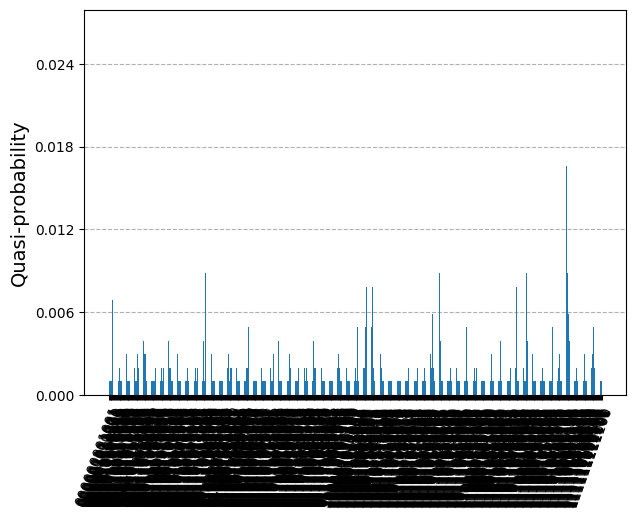

In [76]:
from qiskit.visualization import plot_distribution
plot_distribution(counts,bar_labels=False)

In [77]:
binary_string = max(counts.items(), key=lambda kv: kv[1])[0]
x = np.asarray([int(y) for y in reversed(list(binary_string))])
print(x[0:n])

[0 0 1 1 0 0 0 1]


In [78]:
totalVal = 0 
totalW = 0  
for i in range(0,n):
    if x[i]:
        totalVal += v[i]  
        totalW += w[i] 

print(totalVal, totalW)

45.0 7.0
